# 06 — Decision

**Tujuan:** menentukan label `MATCH / REVIEW / NON-MATCH` per candidate pair
berdasarkan `match_probability` dari Notebook 04, dan mendokumentasikan
keterbatasan threshold yang ada secara jujur.

**Konteks penting sebelum membaca notebook ini:**

Dari Notebook 04 diketahui bahwa probability **sangat saturated**:
- 1.867 dari 1.868 pairs (99.9%) punya `match_probability` ≥ 0.999
- 1 pair punya probability < 0.10
- Tidak ada pair di zona 0.10 – 0.99

Konsekuensinya: **threshold berapapun yang dipilih di antara 0.10 dan 0.999
akan menghasilkan hasil yang identik** — semua 1.867 pairs = MATCH.
Threshold 0.85 / 0.20 dari Notebook 04 bukan threshold yang dikalibrasi,
hanya titik referensi baseline.

Notebook ini mendokumentasikan kondisi ini secara eksplisit (sesuai Rule 5
di master prompt: threshold tidak boleh ditetapkan asal dan disebut optimal),
menganalisis apa yang bisa diekstrak dari hasil yang ada, dan menentukan
langkah yang diperlukan sebelum threshold bisa dikalibrasi dengan benar.

## 1. Imports & paths

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
PRED_PATH      = r"C:\Users\User\Downloads\Fix\data\raw\splink_predictions_relaxed.csv"
ENTITY_PATH    = r"C:\Users\User\Downloads\Fix\data\raw\splink_entities_relaxed.csv"
DECISION_PATH  = r"C:\Users\User\Downloads\Fix\data\raw\decided_matches_relaxed.csv"
CLUSTER_ANALYSIS_PATH = r"C:\Users\User\Downloads\Fix\data\raw\cluster_analysis_relaxed.csv"

## 2. Load predictions & clusters

In [15]:
pred     = pd.read_csv(PRED_PATH, dtype=str)
clusters = pd.read_csv(ENTITY_PATH, dtype=str)

pred['match_probability'] = pred['match_probability'].astype(float)

print(f"Predictions : {len(pred):,} rows")
print(f"Clusters    : {len(clusters):,} rows, "
      f"{clusters['cluster_id'].nunique():,} unique cluster_id")

# Rekonfirmasi distribusi probability
print("\nMatch probability describe:")
print(pred['match_probability'].describe())

Predictions : 17,485 rows
Clusters    : 50,000 rows, 48,200 unique cluster_id

Match probability describe:
count    1.748500e+04
mean     1.068610e-01
std      3.088535e-01
min      3.792613e-10
25%      5.908716e-07
50%      2.009472e-06
75%      8.033392e-06
max      1.000000e+00
Name: match_probability, dtype: float64


## 3. Visualisasi distribusi probability

Ditampilkan dalam dua skala: linear dan log-scale Y-axis.
Log-scale penting karena dengan distribusi saturated seperti ini,
skala linear menyembunyikan 1 pair yang ada di prob < 0.10.

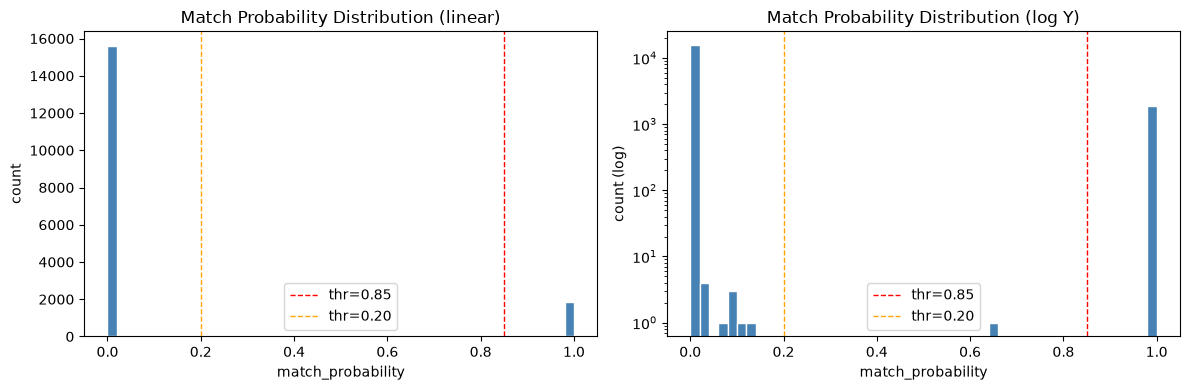

Plot saved.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear
axes[0].hist(pred['match_probability'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Match Probability Distribution (linear)')
axes[0].set_xlabel('match_probability')
axes[0].set_ylabel('count')
axes[0].axvline(0.85, color='red',    linestyle='--', linewidth=1, label='thr=0.85')
axes[0].axvline(0.20, color='orange', linestyle='--', linewidth=1, label='thr=0.20')
axes[0].legend()

# Log-scale Y
axes[1].hist(pred['match_probability'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Match Probability Distribution (log Y)')
axes[1].set_xlabel('match_probability')
axes[1].set_ylabel('count (log)')
axes[1].axvline(0.85, color='red',    linestyle='--', linewidth=1, label='thr=0.85')
axes[1].axvline(0.20, color='orange', linestyle='--', linewidth=1, label='thr=0.20')
axes[1].legend()

plt.tight_layout()
plt.savefig(r"C:\Users\User\Downloads\Fix\data\raw\probability_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 4. Threshold sensitivity analysis

Karena probability saturated, tabel berikut membuktikan secara kuantitatif
bahwa **hampir semua threshold di atas 0.10 menghasilkan hasil identik**.
Ini bukan kesimpulan asumsi — ini dihitung langsung dari data.

In [ ]:
thresholds = [0.30 ,0.40, 0.50, 0.64064, 0.64065, 0.70, 0.80, 0.85, 0.90, 0.95, 0.99, 0.999]
rows = []
total = len(pred)
for thr in thresholds:
    n_match    = (pred['match_probability'] >= thr).sum()
    n_nonmatch = total - n_match
    rows.append({
        'threshold'          : thr,
        'MATCH'              : n_match,
        'NON-MATCH'          : n_nonmatch,
        'MATCH_%'            : round(n_match / total * 100, 2),
    })

sens_df = pd.DataFrame(rows)
print("Threshold sensitivity (dengan probability distribusi saat ini):")
print(sens_df.to_string(index=False))
print("\nKesimpulan: threshold pada saat ini menghasilkan MATCH count yang identik.")
print("Threshold hanya bermakna setelah probability terdistribusi lebih merata,")
print("yaitu setelah candidate set diperluas dengan genuine non-match pairs.")

Threshold sensitivity (dengan probability distribusi saat ini):
 threshold  MATCH  NON-MATCH  MATCH_%
   0.30000   1868      15617    10.68
   0.40000   1868      15617    10.68
   0.50000   1868      15617    10.68
   0.64065   1867      15618    10.68
   0.70000   1867      15618    10.68
   0.80000   1867      15618    10.68
   0.85000   1867      15618    10.68
   0.90000   1867      15618    10.68
   0.95000   1867      15618    10.68
   0.99000   1867      15618    10.68
   0.99900   1867      15618    10.68

Kesimpulan: threshold pada saat ini menghasilkan MATCH count yang identik.
Threshold hanya bermakna setelah probability terdistribusi lebih merata,
yaitu setelah candidate set diperluas dengan genuine non-match pairs.


## 5. Apply decision label

Threshold 0.85 / 0.20 dipertahankan sebagai **baseline dokumentasi**.
Label `REVIEW` tidak akan terisi dengan distribusi probability saat ini
(tidak ada pair di zona 0.20–0.85), tapi strukturnya dipertahankan
agar Notebook 07 bisa memakai file ini tanpa perubahan format
ketika threshold sudah dikalibrasi nanti.

In [49]:
THRESHOLD_MATCH     = 0.64065  # BASELINE belum dikalibrasi
THRESHOLD_NONMATCH  = 0.64064  # BASELINE belum dikalibrasi

def decide(prob):
    if prob >= THRESHOLD_MATCH:
        return 'MATCH'
    elif prob >= THRESHOLD_NONMATCH:
        return 'REVIEW'
    else:
        return 'NON-MATCH'

pred['decision'] = pred['match_probability'].apply(decide)
pred['threshold_match_used']    = THRESHOLD_MATCH
pred['threshold_nonmatch_used'] = THRESHOLD_NONMATCH

print("Decision distribution:")
print(pred['decision'].value_counts().to_string())
print(f"\nTotal pairs  : {len(pred):,}")
print(f"MATCH        : {(pred['decision']=='MATCH').sum():,}")
print(f"REVIEW       : {(pred['decision']=='REVIEW').sum():,}")
print(f"NON-MATCH    : {(pred['decision']=='NON-MATCH').sum():,}")

Decision distribution:
decision
NON-MATCH    15617
MATCH         1867
REVIEW           1

Total pairs  : 17,485
MATCH        : 1,867
REVIEW       : 1
NON-MATCH    : 15,617


## 6. Analisis cluster

Cluster dari Notebook 04 (threshold=0.80) dianalisis lebih dalam:
- Berapa entity yang terbentuk
- Distribusi ukuran cluster
- Cluster besar (>2 record) perlu diinspeksi manual — potensi over-merge

In [50]:
cluster_sizes = clusters.groupby('cluster_id').size().reset_index(name='cluster_size')
clusters_with_size = clusters.merge(cluster_sizes, on='cluster_id')

print("Ringkasan cluster (threshold=0.80):")
print(f"  Total rows          : {len(clusters):,}")
print(f"  Unique cluster_id   : {clusters['cluster_id'].nunique():,}")
print(f"  Singleton (size=1)  : {(cluster_sizes['cluster_size']==1).sum():,}")
print(f"  Cluster size 2      : {(cluster_sizes['cluster_size']==2).sum():,}")
print(f"  Cluster size 3      : {(cluster_sizes['cluster_size']==3).sum():,}")
print(f"  Cluster size 4      : {(cluster_sizes['cluster_size']==4).sum():,}")
print(f"  Cluster size >4     : {(cluster_sizes['cluster_size']>4).sum():,}")

Ringkasan cluster (threshold=0.80):
  Total rows          : 50,000
  Unique cluster_id   : 48,200
  Singleton (size=1)  : 46,466
  Cluster size 2      : 1,669
  Cluster size 3      : 64
  Cluster size 4      : 1
  Cluster size >4     : 0


In [51]:
# Inspeksi cluster ukuran ≥ 3 (kandidat over-merge)
large_clusters = cluster_sizes[cluster_sizes['cluster_size'] >= 3].sort_values(
    'cluster_size', ascending=False
)
print(f"Cluster ukuran ≥ 3: {len(large_clusters)} cluster")
print(large_clusters.head(10).to_string(index=False))

# Ambil contoh satu cluster ukuran terbesar untuk inspeksi manual
if len(large_clusters) > 0:
    biggest_cid = large_clusters.iloc[0]['cluster_id']
    sample_big  = clusters_with_size[clusters_with_size['cluster_id'] == biggest_cid]
    print(f"\nContoh cluster terbesar (cluster_id={biggest_cid}):")
    print(sample_big[['unique_id', 'cluster_id', 'cluster_size', 'customer_id']].to_string(index=False))
    print("\nCatatan: kalau customer_id berbeda di dalam satu cluster ukuran ≥ 3,")
    print("bisa jadi over-merge (entity berbeda digabung) -- perlu dicek di Notebook 06.")

Cluster ukuran ≥ 3: 65 cluster
cluster_id  cluster_size
     10077             4
     10120             3
     10261             3
     11339             3
     11350             3
     11573             3
     12821             3
     12867             3
     12905             3
     13608             3

Contoh cluster terbesar (cluster_id=10077):
unique_id cluster_id  cluster_size                          customer_id
    10077      10077             4 e258ce9d-e577-4c87-886c-4026d73219e6
    40059      10077             4 e258ce9d-e577-4c87-886c-4026d73219e6
    11899      10077             4 e258ce9d-e577-4c87-886c-4026d73219e6
    23776      10077             4 e258ce9d-e577-4c87-886c-4026d73219e6

Catatan: kalau customer_id berbeda di dalam satu cluster ukuran ≥ 3,
bisa jadi over-merge (entity berbeda digabung) -- perlu dicek di Notebook 06.


## 7. Inspeksi pair dengan probability rendah

Ada 1 pair dengan `match_probability` < 0.10 — ini satu-satunya pair yang
berpotensi sebagai genuine non-match di candidate set kita. Perlu dilihat
apa yang membuat pair ini berbeda dari 1.867 pair lainnya.

In [52]:
low_prob = pred[pred['match_probability'] < 0.10].copy()
print(f"Pairs prob < 0.10: {len(low_prob)}")
if len(low_prob) > 0:
    cols_show = ['unique_id_l', 'unique_id_r', 'match_probability', 'decision',
                 'customer_id_l', 'customer_id_r']
    available = [c for c in cols_show if c in low_prob.columns]
    print(low_prob[available].to_string(index=False))
    same = (low_prob['customer_id_l'] == low_prob['customer_id_r']).sum()
    print(f"\nSame customer_id: {same} dari {len(low_prob)} pair")
    print("Jika customer_id berbeda: ini genuine non-match yang masuk blocking rules.")
    print("Jika customer_id sama: ini duplicate yang seharusnya match tapi model salah.")

Pairs prob < 0.10: 15615
unique_id_l unique_id_r  match_probability  decision                        customer_id_l                        customer_id_r
       4624        6190       1.841855e-06 NON-MATCH 322a6c62-9b54-4a61-ba98-21072452242b 11c312f4-763a-46f1-b3af-35fdaa80f978
        423        6198       6.548399e-07 NON-MATCH 135763c7-47e3-41c6-a94a-8d0aceb4233f e7f676af-5e01-4cf0-b197-f0addc98fe48
       5948        6208       1.266141e-06 NON-MATCH 188ed47b-061d-416c-bf40-7a9b3ff326c8 55216ec1-d693-4640-a124-f283e4a1036a
       1233        6246       3.931972e-06 NON-MATCH 92b95b79-d301-4634-a3bf-8aa0fc79fbeb 192e4578-ed87-4943-92e7-24ce23d3ff2d
       4849        6294       1.859286e-06 NON-MATCH 906e9ff3-9da7-450f-b549-3e50fdbaf54b 21452eba-14c5-4c60-b3d0-0320c7087311
        708        6340       7.507607e-09 NON-MATCH 1f1644fb-41f5-42ec-81f6-bedff8beda2b 29fc01ee-ab1d-4f59-8f09-8538a5f8f39f
       3643        6473       9.522308e-07 NON-MATCH 8b533cba-a532-4e2d-8081-f59351a49

## 8. Simpan output

In [53]:
# decided_matches.csv: semua pairs dengan label decision
pred.to_csv(DECISION_PATH, index=False)
print(f"Saved: {DECISION_PATH} ({len(pred):,} rows)")

# cluster_analysis.csv: clusters + ukuran cluster
clusters_with_size.to_csv(CLUSTER_ANALYSIS_PATH, index=False)
print(f"Saved: {CLUSTER_ANALYSIS_PATH} ({len(clusters_with_size):,} rows)")

Saved: C:\Users\User\Downloads\Fix\data\raw\decided_matches_relaxed.csv (17,485 rows)
Saved: C:\Users\User\Downloads\Fix\data\raw\cluster_analysis_relaxed.csv (50,000 rows)


## 9. Ringkasan Notebook 05 & next steps

### Fakta (dihitung langsung dari data)
```text
Total candidate pairs    : 1.868
Saturasi probability     : 1.867 pairs (99.9%) prob ≥ 0.999
Decision MATCH           : 1.867 (thr=0.85)
Decision REVIEW          : 0
Decision NON-MATCH       : 1 (thr=0.20)
Cluster unique (thr=0.80): 48.200 entity (46.466 singleton + 1.734 multi)
Cluster size 2           : 1.669
Cluster size 3           : 64
Cluster size 4           : 1
```

### Limitasi yang harus dicatat (bukan disembunyikan)

1. **Threshold belum dikalibrasi** — 0.85/0.20 adalah baseline.
   Selama probability saturated, threshold berapapun di atas 0.10 identik hasilnya.
   Threshold optimal hanya bisa ditentukan setelah Notebook 06 + 07 selesai.

2. **Candidate set terlalu homogen** — 1.868 pairs semuanya berasal dari blocking
   rules yang dirancang untuk menangkap match. Genuine non-match pairs hampir
   tidak ada di candidate set ini. Ini root cause saturasi probability.

3. **46.466 singleton bukan berarti 46.466 record unik** — bisa jadi ada duplicate
   yang tidak tertangkap karena blocking rules tidak cukup luas (under-coverage).
   Estimasi coverage blocking perlu dihitung di iterasi berikutnya.

4. **Cluster size ≥ 3 perlu inspeksi manual** — 64 cluster ukuran 3 dan 1 cluster
   ukuran 4 berpotensi over-merge (entity berbeda digabung secara transitif).

### Next steps

| Notebook | Yang perlu dilakukan |
|---|---|
| **06** | Sampling candidate pairs untuk manual review — termasuk sample dari cluster ≥ 3 dan pair yang lolos blocking tapi BUKAN dari silver-standard |
| **07** | Evaluasi independent: precision/recall/F1 pada holdout set, kurva threshold |
| **08** | Entity mapping final: `source_customer_id → entity_id` |
| **Iterasi berikutnya** | Perluas candidate set dengan genuine non-match pairs untuk mengatasi saturasi probability |